### Construção das origens 
Utilizando centróides da grade estatística do IBGE:


Grade Estatística IBGE

↓ Seleciona células com população > 0

↓ Calcula o centróide de cada célula

↓ Conecta o centróide ao nó mais próximo da rede

Origem da viagem


In [1]:
import sys
from pathlib import Path

# adiciona a raiz do projeto ao Python
sys.path.append(str(Path.cwd().parent))

In [2]:
# Bibliotecas
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import json

Carrega grade estatistica

In [3]:
# Grade do IBGE ID_14
gridId14 = gpd.read_file("../data/grade_estatistica_id14-2022/grade_id14.shp")
print(gridId14.columns)
gridId14.info()

Index(['geometry'], dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 582324 entries, 0 to 582323
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   geometry  582324 non-null  geometry
dtypes: geometry(1)
memory usage: 4.4 MB


In [4]:
# Grade do IBGE Brasil
gridBr = gpd.read_file("../data/grade_estatistica_5k_BR-2022/BR5KM.shp")
print(gridBr.columns)
# print(grid.columns.tolist())
gridBr.info()


Index(['nome_5KM', 'TOTAL', 'TOTAL_DOM', 'geometry'], dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 358080 entries, 0 to 358079
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   nome_5KM   358080 non-null  str     
 1   TOTAL      358080 non-null  int64   
 2   TOTAL_DOM  358080 non-null  int64   
 3   geometry   358080 non-null  geometry
dtypes: geometry(1), int64(2), str(1)
memory usage: 15.6 MB


In [5]:
# Grade do IBGE POA
grid = gpd.read_file("../data/grade_estatistica_POA-2022/grade2022.shp")
print(grid.columns)
grid.info()

Index(['fid', 'ID_UNICO', 'nome_1KM', 'nome_5KM', 'nome_10KM', 'nome_50KM',
       'nome_100KM', 'nome_500KM', 'QUADRANTE', 'MASC', 'FEM', 'POP',
       'DOM_OCU', 'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12879 entries, 0 to 12878
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   fid         12879 non-null  float64 
 1   ID_UNICO    12879 non-null  str     
 2   nome_1KM    12879 non-null  str     
 3   nome_5KM    12879 non-null  str     
 4   nome_10KM   12879 non-null  str     
 5   nome_50KM   12879 non-null  str     
 6   nome_100KM  12879 non-null  str     
 7   nome_500KM  12879 non-null  str     
 8   QUADRANTE   12879 non-null  str     
 9   MASC        12879 non-null  float64 
 10  FEM         12879 non-null  float64 
 11  POP         12879 non-null  float64 
 12  DOM_OCU     12879 non-null  float64 
 13  Shape_Leng  12879 non-nu

Define origem
(Selecionando apenas as celulas habitadas)

In [6]:
# Apenas células habitadas
# origins = grid[grid["TOTAL"] > 0].copy() # P/ grade BR e ID14
origins = grid[grid["POP"] > 0].copy() # P/ grade POA

# Centróide da célula
origins["geometry"] = origins.geometry.centroid

print(origins["geometry"].head())



234    POINT (474386.204 6669552.438)
235     POINT (474578.68 6669554.914)
236     POINT (474383.84 6669760.062)
237    POINT (474576.318 6669762.539)
238    POINT (474381.475 6669967.684)
Name: geometry, dtype: geometry


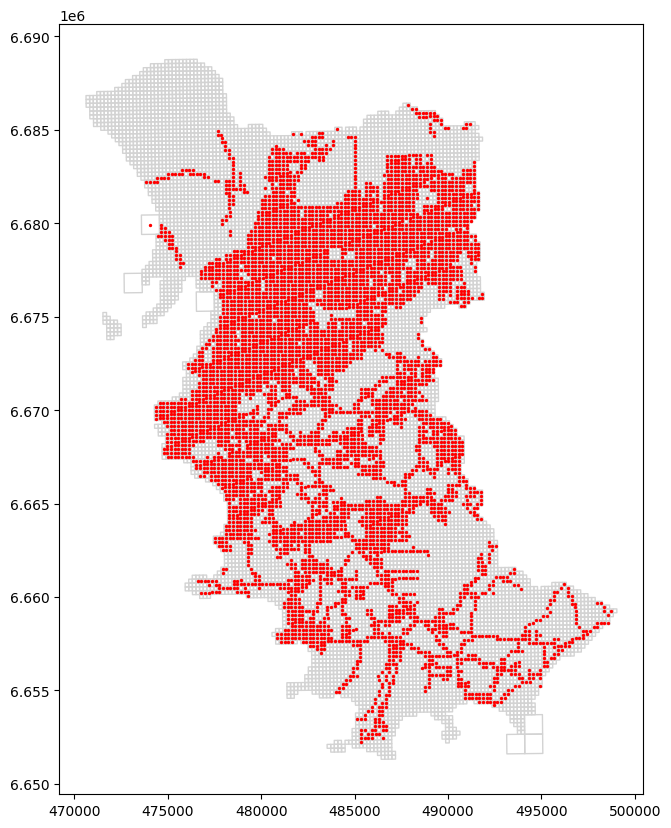

In [7]:
figure, axis = plt.subplots(figsize=(10,10))

grid.plot(ax=axis, facecolor="none", edgecolor="lightgray")
origins.plot(ax=axis, color="red", markersize=2)

plt.show()

In [8]:
print(f"Número de células habitadas: {len(origins)}")

Número de células habitadas: 6189


Verifica sistema de coordenadas

In [9]:
# Verifica o sistema de coordenadas
print(origins.crs)

# Converte para o sistema de coordenadas desejado
#print(origins["geometry"].head().to_crs(epsg=31982))  

EPSG:31982


Carrega a rede viaria e selecionas os nós

In [30]:
# Poa
graph = ox.load_graphml("../data/graph/rede-poa.graphml")

In [11]:
"""
# Carrega o arquivo de json de configuração
#   open -> inputs: arquivo, modo de abertura, codificação
with open("../config/config.json", "r", encoding="utf-8") as config_file:
    config = json.load(config_file)

# Configurações
study_area = config["study_area"]

cidade = study_area["place"]
network_type = study_area["network_type"]


# Monta a string
place = cidade
print(f"Baixando a rede de ruas de {place}...")
"""

'\n# Carrega o arquivo de json de configuração\n#   open -> inputs: arquivo, modo de abertura, codificação\nwith open("../config/config.json", "r", encoding="utf-8") as config_file:\n    config = json.load(config_file)\n\n# Configurações\nstudy_area = config["study_area"]\n\ncidade = study_area["place"]\nnetwork_type = study_area["network_type"]\n\n\n# Monta a string\nplace = cidade\nprint(f"Baixando a rede de ruas de {place}...")\n'

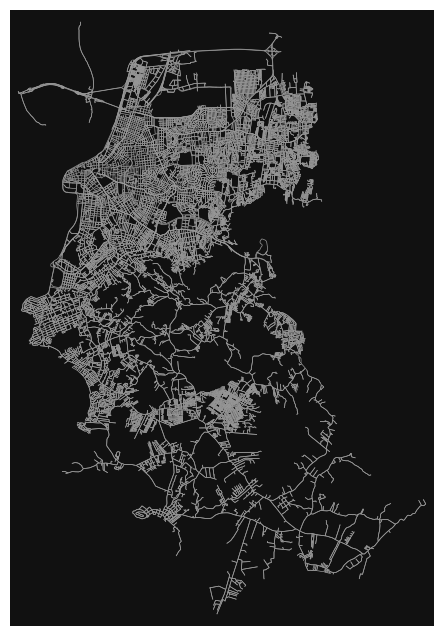

In [31]:
#graph = ox.graph_from_place(place, network_type="drive")

figure, axis = ox.plot_graph(
    graph,
    node_size=0,
    edge_linewidth=0.5
)

In [21]:
# Converte para GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(graph)

In [22]:
# Verifica o sistema de coordenadas
print(origins.crs)
print(graph.graph["crs"])

EPSG:31982
EPSG:31982


In [15]:
# Corrije o sistema de coordenadas
graph = ox.project_graph(graph, to_crs="EPSG:31982")
print(graph.graph["crs"])
print(origins.crs)

EPSG:31982
EPSG:31982


In [23]:
# Relaciona cada nó da rede com a origem mais próxima
origins["node"] = ox.distance.nearest_nodes(
    graph,
    X=origins.geometry.x,
    Y=origins.geometry.y
)

"""
osmnx faz algo como
for origem in origens:

    pega_x()

    pega_y()

    procura o nó mais próximo

    devolve o id'
"""

print(origins.head())

     origin_id          ID_UNICO       nome_1KM       nome_5KM  \
234      235.0  200ME52736N79976  1KME5273N7997  5KME5270N7995   
235      236.0  200ME52738N79976  1KME5273N7997  5KME5270N7995   
236      237.0  200ME52736N79978  1KME5273N7997  5KME5270N7995   
237      238.0  200ME52738N79978  1KME5273N7997  5KME5270N7995   
238      239.0  200ME52736N79980  1KME5273N7997  5KME5270N7995   

          nome_10KM       nome_50KM       nome_100KM       nome_500KM  \
234  10KME5270N7990  50KME5250N7950  100KME5200N7950  500KME4800N7850   
235  10KME5270N7990  50KME5250N7950  100KME5200N7950  500KME4800N7850   
236  10KME5270N7990  50KME5250N7950  100KME5200N7950  500KME4800N7850   
237  10KME5270N7990  50KME5250N7950  100KME5200N7950  500KME4800N7850   
238  10KME5270N7990  50KME5250N7950  100KME5200N7950  500KME4800N7850   

    QUADRANTE  MASC   FEM    POP  DOM_OCU  Shape_Leng  Shape_Area  \
234     ID_14  26.0  29.0   55.0     16.0    0.007743    0.000004   
235     ID_14  50.0  55.0 

In [24]:
# Renomeia a coluna "fid" para "origin_id"
origins.columns
origins = origins.rename(columns={"fid": "origin_id"})

Salva origens

In [25]:
origins.to_file(
    "../data/o-d/origens_porto_alegre.gpkg",
    layer="origens",
    driver="GPKG"
)